Saved: ../output/refinement_figures/combined_cache_efficiency_grid.pdf


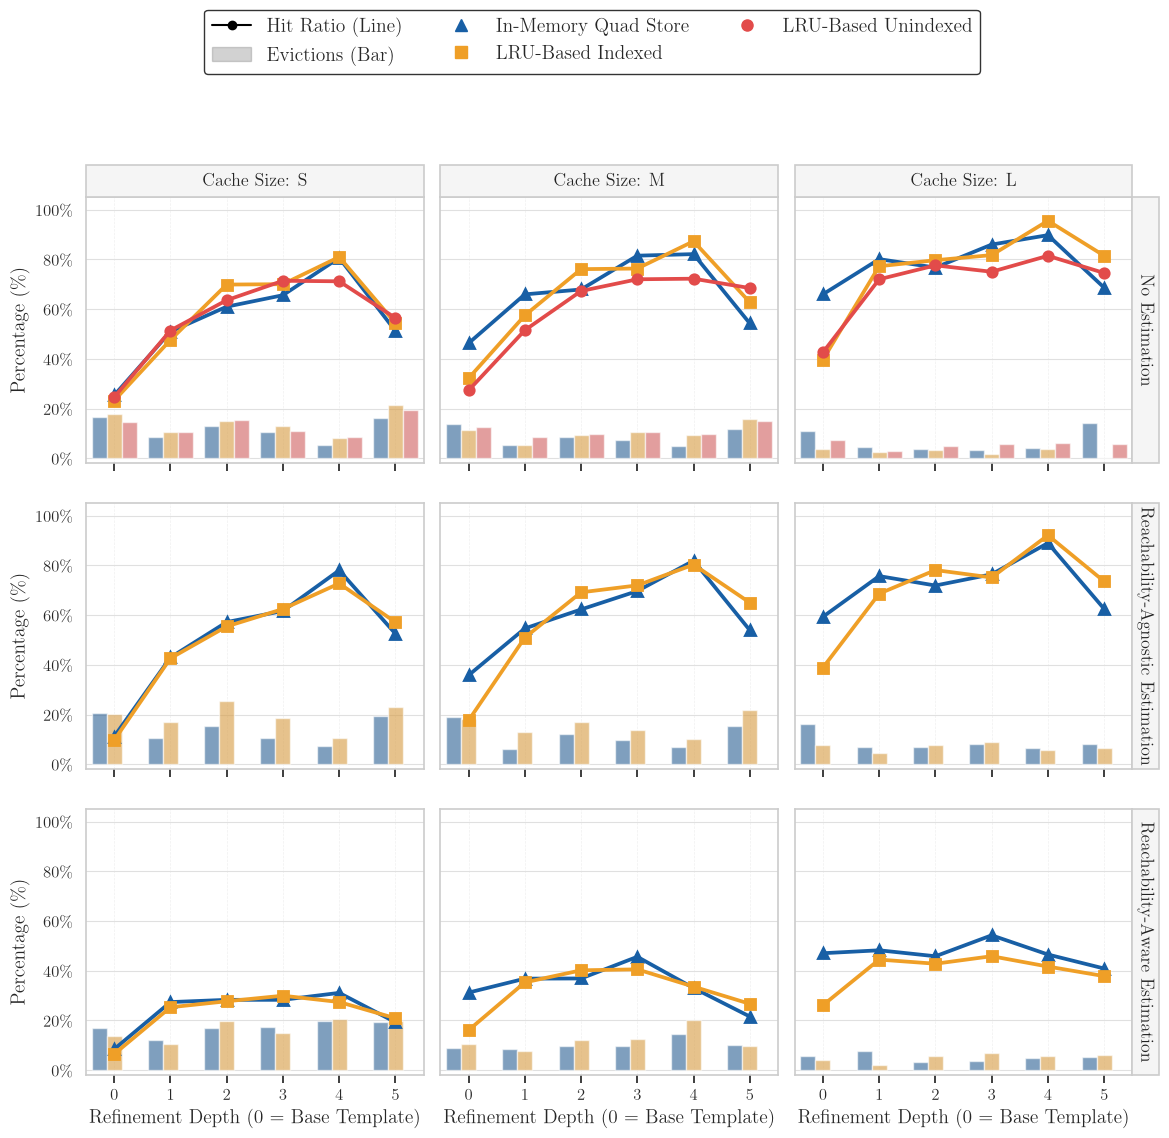

Saved: ../output/refinement_figures/temporal_throughput_combined_grid.pdf


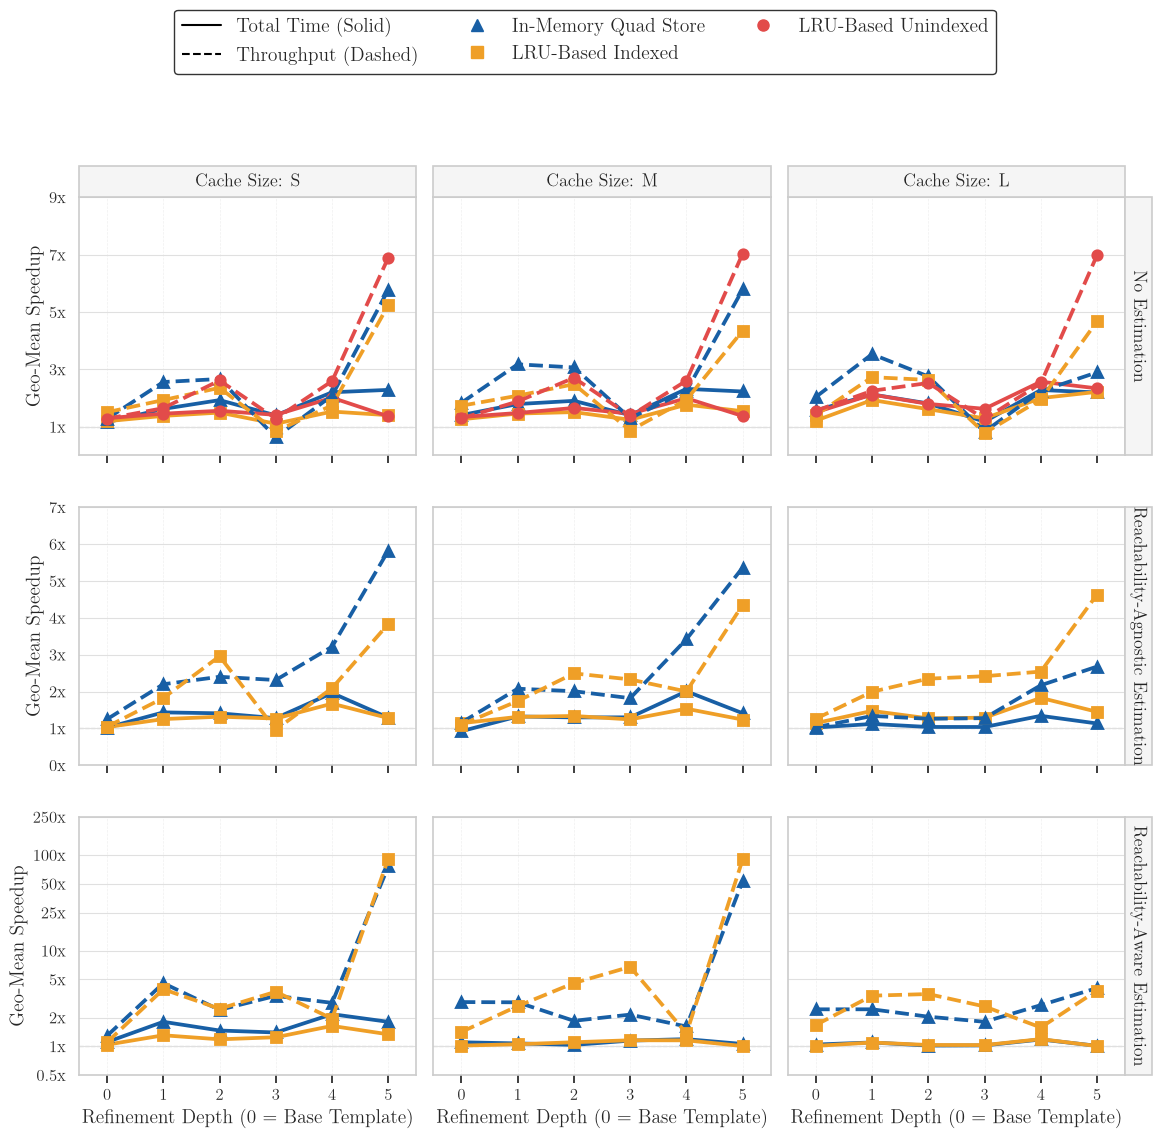

In [19]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import matplotlib.lines as mlines
from scipy.stats import gmean

# Enable inline plotting for Jupyter Notebooks
# %matplotlib inline

# Hardcoded unified colors for the 4 base caching approaches
ALGORITHM_COLORS = {
    'LRU-Based Unindexed': '#E24B4A',
    'LRU-Based Indexed': '#EF9F27',
    'In-Memory Quad Store': '#185FA5',
    'Disk-Based Quad Store': '#888888'
}

# Hardcoded unique markers for grayscale readability
ALGORITHM_MARKERS = {
    'LRU-Based Unindexed': 'o',   # Circle
    'LRU-Based Indexed': 's',     # Square
    'In-Memory Quad Store': '^',  # Triangle
    'Disk-Based Quad Store': 'D'  # Diamond
}

def safe_gmean(x):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    valid_x = x.dropna()
    valid_x = valid_x[valid_x > 0]
    if valid_x.empty:
        return np.nan
    return gmean(valid_x)

def get_algorithm_info(location_string):
    """
    Parses the filename to extract the renamed base caching approach,
    the cache size, and the estimation strategy group.
    """
    filename = os.path.basename(location_string).replace('.json', '')
    clean_name = filename.replace('query-results-raw-', '')

    if clean_name[-2:].lower() in ['-s', '-m', '-l']:
        size = clean_name[-1].upper()
        base_type = clean_name[:-2]
    else:
        size = 'Unknown'
        base_type = clean_name

    mapping = {
        'unindexed': ('LRU-Based Unindexed', 'No Estimation'),
        'index': ('LRU-Based Indexed', 'No Estimation'),
        'index-e': ('LRU-Based Indexed', 'Reachability-Agnostic Estimation'),
        'index-e-o': ('LRU-Based Indexed', 'Reachability-Aware Estimation'),
        'store': ('In-Memory Quad Store', 'No Estimation'),
        'store-e': ('In-Memory Quad Store', 'Reachability-Agnostic Estimation'),
        'store-e-o': ('In-Memory Quad Store', 'Reachability-Aware Estimation'),
        'disk': ('Disk-Based Quad Store', 'No Estimation'),
        'disk-e': ('Disk-Based Quad Store', 'Reachability-Agnostic Estimation'),
        'disk-e-o': ('Disk-Based Quad Store', 'Reachability-Aware Estimation')
    }

    mapping.update({
        'cache': ('LRU-Based Unindexed', 'No Estimation'),
        'query-cache': ('LRU-Based Indexed', 'No Estimation'),
        'query-cache-estimate': ('LRU-Based Indexed', 'Reachability-Agnostic Estimation')
    })

    base_alg, est_group = mapping.get(base_type, (base_type, 'No Estimation'))
    return base_alg, size, est_group


def investigate_refinement_patterns(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                time_val = item.get('time')
                timestamps = item.get("timestamps", [])
                num_timestamps = len(timestamps)

                time_first = timestamps[0] if num_timestamps > 0 else pd.NA
                time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
                has_results = num_timestamps > 0

                compute_time = pd.NA
                if has_results and pd.notna(time_first) and pd.notna(time_val):
                    compute_time = max(0, time_val - time_first)

                throughput = 0.0
                if has_results and pd.notna(time_last) and time_last > 0:
                    throughput = num_timestamps / time_last

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'time': time_val,
                    "time_first": time_first,
                    "compute_time": compute_time,
                    "throughput": throughput,
                    "has_results": has_results,
                    "num_timestamps": num_timestamps,
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:cacheSourceStateIndexedQuadStore")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
        time_baseline=('time', 'median'),
        time_first_baseline=('time_first', 'median'),
        throughput_baseline=('throughput', 'median')
    ).reset_index()

    final_cache_dfs = []
    for cache_loc in cache_locations:
        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        base_alg, cache_size, est_group = get_algorithm_info(cache_loc)

        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
            time=('time', 'median'),
            time_first=('time_first', 'median'),
            compute_time=('compute_time', 'median'),
            throughput=('throughput', 'median'),
            hit_ratio=('hit_ratio', 'median'),
            eviction_percentage=('eviction_percentage', 'median')
        ).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_depth'], how='inner')

        df_merged['speedup_total'] = df_merged['time_baseline'] / df_merged['time']
        df_merged['speedup_first'] = df_merged['time_first_baseline'] / df_merged['time_first']

        df_merged['speedup_throughput'] = np.where(
            (df_merged['throughput_baseline'] > 0) & (df_merged['throughput'] > 0),
            df_merged['throughput'] / df_merged['throughput_baseline'],
            np.nan
        )

        df_merged['algorithm'] = base_alg
        df_merged['cache_size'] = cache_size
        df_merged['algorithm_group'] = est_group

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def _apply_lncs_theme():
    rc_params = {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
        "axes.titlesize": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 14,
        "axes.edgecolor": "#CCCCCC",
        "axes.linewidth": 1.2
    }
    sns.set_theme(style="whitegrid", rc=rc_params)

def plot_refinement_cache_metrics(df, save_path="."):
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    _apply_lncs_theme()

    plot_df = df.copy()
    plot_df['hit_ratio_pct'] = plot_df['hit_ratio'] * 100

    groups = ['No Estimation', 'Reachability-Agnostic Estimation', 'Reachability-Aware Estimation']
    groups = [g for g in groups if g in plot_df['algorithm_group'].unique()]

    cache_sizes = ['S', 'M', 'L']
    all_algorithms = sorted(plot_df['algorithm'].dropna().unique().tolist())

    nrows = len(groups)
    ncols = len(cache_sizes)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows),
                             sharex=True, sharey=True,
                             gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

    if nrows == 1: axes = np.array([axes])
    if ncols == 1: axes = axes.reshape(-1, 1)

    for r, group in enumerate(groups):
        for c, cache_size in enumerate(cache_sizes):
            ax = axes[r, c]

            # --- Facet Grid Margin Titles ---
            # 1. Column Titles (Top Row Only)
            if r == 0:
                rect = patches.Rectangle((0, 1), 1, 0.12, transform=ax.transAxes,
                                         facecolor='#F5F5F5', edgecolor='#CCCCCC',
                                         linewidth=1.2, clip_on=False, zorder=10)
                ax.add_patch(rect)
                ax.text(0.5, 1.06, f"Cache Size: {cache_size}", transform=ax.transAxes,
                        ha='center', va='center', fontsize=13, fontweight='bold', color='#222222', zorder=11)

            # 2. Row Titles (Rightmost Column Only)
            if c == ncols - 1:
                rect = patches.Rectangle((1, 0), 0.08, 1, transform=ax.transAxes,
                                         facecolor='#F5F5F5', edgecolor='#CCCCCC',
                                         linewidth=1.2, clip_on=False, zorder=10)
                ax.add_patch(rect)
                ax.text(1.04, 0.5, group, transform=ax.transAxes,
                        ha='center', va='center', fontsize=13, fontweight='bold', color='#222222',
                        rotation=-90, zorder=11)
            # --------------------------------

            cell_df = plot_df[(plot_df['algorithm_group'] == group) & (plot_df['cache_size'] == cache_size)]
            valid_df = cell_df.dropna(subset=['hit_ratio_pct', 'eviction_percentage'], how='all')

            if not valid_df.empty:
                current_markers = [ALGORITHM_MARKERS[alg] for alg in all_algorithms]

                sns.barplot(data=valid_df, x="refinement_depth", y="eviction_percentage",
                            hue="algorithm", hue_order=all_algorithms,
                            palette=ALGORITHM_COLORS, alpha=0.6, ax=ax, errorbar=None, legend=False)

                sns.pointplot(data=valid_df, x="refinement_depth", y="hit_ratio_pct",
                              hue="algorithm", hue_order=all_algorithms,
                              palette=ALGORITHM_COLORS,
                              markers=current_markers,
                              linestyles='-',
                              ax=ax, errorbar=None, legend=False)

            ax.set_ylim(-2, 105)
            ax.grid(True, which='major', axis='y', color='#E0E0E0', linestyle='-', linewidth=0.8)
            ax.grid(True, which='major', axis='x', color='#F0F0F0', linestyle='--', linewidth=0.5)

            ax.set_xticks(range(6))
            ax.set_xticklabels([str(i) for i in range(6)])

            if c == 0:
                ax.set_ylabel(r"Percentage (\%)", fontsize=14)
                ax.yaxis.set_major_formatter(ticker.PercentFormatter())
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

            if r == nrows - 1:
                ax.set_xlabel(r"Refinement Depth (0 = Base Template)", fontsize=14)
                ax.tick_params(axis='x', bottom=True, labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis='x', bottom=True, labelbottom=False)

    custom_handles = [
        mlines.Line2D([], [], color='black', marker='o', linestyle='-', label='Hit Ratio (Line)'),
        patches.Patch(color='gray', alpha=0.35, label='Evictions (Bar)')
    ]

    for alg in all_algorithms:
        custom_handles.append(
            mlines.Line2D([], [], color=ALGORITHM_COLORS[alg], marker=ALGORITHM_MARKERS[alg],
                          linestyle='', markersize=8, label=alg)
        )

    fig.legend(handles=custom_handles,
               loc='lower center', bbox_to_anchor=(0.5, 0.98),
               ncol=3, frameon=True, edgecolor='black')

    save_target = os.path.join(save_path, "combined_cache_efficiency_grid.pdf")
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()


def plot_temporal_throughput_line(df, save_path=".", log_scale_groups=None, max_y_cap=None):
    if df.empty:
        print("DataFrame is empty.")
        return

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    if log_scale_groups is None:
        log_scale_groups = []

    _apply_lncs_theme()

    df_clean = df.copy()
    for col in ['speedup_total', 'speedup_throughput']:
        df_clean[col] = pd.to_numeric(df_clean[col]).fillna(0)

    melted_df = df_clean.melt(
        id_vars=['cache_size', 'algorithm', 'algorithm_group', 'refinement_depth'],
        value_vars=['speedup_total', 'speedup_throughput'],
        var_name='Metric',
        value_name='Speedup'
    )

    melted_df['Metric'] = melted_df['Metric'].replace({
        'speedup_total': 'Total Time',
        'speedup_throughput': 'Throughput'
    })

    groups = ['No Estimation', 'Reachability-Agnostic Estimation', 'Reachability-Aware Estimation']
    groups = [g for g in groups if g in melted_df['algorithm_group'].unique()]

    cache_sizes = ['S', 'M', 'L']

    valid_global_df = melted_df[melted_df['Speedup'] > 0]
    all_algorithms = sorted(valid_global_df['algorithm'].dropna().unique().tolist())

    nrows = len(groups)
    ncols = len(cache_sizes)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows),
                             sharex=True, sharey='row',
                             gridspec_kw={'wspace': 0.05, 'hspace': 0.20})

    if nrows == 1: axes = np.array([axes])
    if ncols == 1: axes = axes.reshape(-1, 1)

    for r, group in enumerate(groups):
        use_log_this_group = group in log_scale_groups

        for c, cache_size in enumerate(cache_sizes):
            ax = axes[r, c]

            # --- Facet Grid Margin Titles ---
            # 1. Column Titles (Top Row Only)
            if r == 0:
                rect = patches.Rectangle((0, 1), 1, 0.12, transform=ax.transAxes,
                                         facecolor='#F5F5F5', edgecolor='#CCCCCC',
                                         linewidth=1.2, clip_on=False, zorder=10)
                ax.add_patch(rect)
                ax.text(0.5, 1.06, f"Cache Size: {cache_size}", transform=ax.transAxes,
                        ha='center', va='center', fontsize=13, fontweight='bold', color='#222222', zorder=11)

            # 2. Row Titles (Rightmost Column Only)
            if c == ncols - 1:
                rect = patches.Rectangle((1, 0), 0.08, 1, transform=ax.transAxes,
                                         facecolor='#F5F5F5', edgecolor='#CCCCCC',
                                         linewidth=1.2, clip_on=False, zorder=10)
                ax.add_patch(rect)
                ax.text(1.04, 0.5, group, transform=ax.transAxes,
                        ha='center', va='center', fontsize=13, fontweight='bold', color='#222222',
                        rotation=-90, zorder=11)
            # --------------------------------

            cell_df = valid_global_df[(valid_global_df['algorithm_group'] == group) &
                                      (valid_global_df['cache_size'] == cache_size)]

            if not cell_df.empty:
                current_markers = [ALGORITHM_MARKERS[alg] for alg in all_algorithms]

                sns.pointplot(data=cell_df[cell_df['Metric'] == 'Total Time'],
                              x="refinement_depth", y="Speedup",
                              hue="algorithm", hue_order=all_algorithms,
                              palette=ALGORITHM_COLORS,
                              markers=current_markers,
                              linestyles="-",
                              estimator=safe_gmean,
                              ax=ax, errorbar=None, legend=False)

                sns.pointplot(data=cell_df[cell_df['Metric'] == 'Throughput'],
                              x="refinement_depth", y="Speedup",
                              hue="algorithm", hue_order=all_algorithms,
                              palette=ALGORITHM_COLORS,
                              markers=current_markers,
                              linestyles="--",
                              estimator=safe_gmean,
                              ax=ax, errorbar=None, legend=False)

            ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
            ax.grid(True, which='major', axis='y', color='#E0E0E0', linestyle='-', linewidth=0.8)
            ax.grid(True, which='major', axis='x', color='#F0F0F0', linestyle='--', linewidth=0.5)

            ax.set_xticks(range(6))
            ax.set_xticklabels([str(i) for i in range(6)])

            if use_log_this_group:
                ax.set_yscale('log')
                custom_ticks = [0.5, 1, 2, 5, 10, 25, 50, 100, 250]
                ax.set_yticks(custom_ticks)
                ax.set_yticklabels([f'{t:g}x' for t in custom_ticks])
                ax.set_ylim(bottom=0.5)
            else:
                ylim = ax.get_ylim()
                if max_y_cap is not None:
                    ax.set_ylim(bottom=0, top=min(max(ylim[1], 2.5), max_y_cap))
                else:
                    ax.set_ylim(bottom=0, top=max(ylim[1], 2.5))

                ylim = ax.get_ylim()
                ticks = ax.get_yticks()
                if len(ticks) > 1:
                    step = ticks[1] - ticks[0]
                    if step > 0:
                        min_tick = 1.0 - np.ceil((1.0 - ylim[0]) / step) * step
                        max_tick = 1.0 + np.ceil((ylim[1] - 1.0) / step) * step
                        new_ticks = np.arange(min_tick, max_tick + step / 2, step)
                        new_ticks = new_ticks[new_ticks >= 0]
                        ax.set_yticks(new_ticks)

                ax.set_ylim(bottom=0, top=ax.get_ylim()[1])
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

            if c == 0:
                ax.set_ylabel(r"Geo-Mean Speedup", fontsize=14)
                ax.tick_params(labelleft=True)
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

            if r == nrows - 1:
                ax.set_xlabel(r"Refinement Depth (0 = Base Template)", fontsize=14)
                ax.tick_params(axis='x', bottom=True, labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis='x', bottom=True, labelbottom=False)

    custom_handles = [
        mlines.Line2D([], [], color='black', linestyle='-', label='Total Time (Solid)'),
        mlines.Line2D([], [], color='black', linestyle='--', label='Throughput (Dashed)')
    ]

    for alg in all_algorithms:
        custom_handles.append(
            mlines.Line2D([], [], color=ALGORITHM_COLORS[alg], marker=ALGORITHM_MARKERS[alg],
                          linestyle='', markersize=8, label=alg)
        )

    fig.legend(handles=custom_handles,
               loc='lower center', bbox_to_anchor=(0.5, 0.98),
               ncol=3, frameon=True, edgecolor='black')

    save_target = os.path.join(save_path, f"temporal_throughput_combined_grid.pdf")
    plt.savefig(save_target, bbox_inches='tight')
    print(f"Saved: {save_target}")
    plt.show()

# Execution block
if __name__ == "__main__":
    data_dir = os.path.join("..", "data", "data-standard")

    raw_data_unindexed_s = os.path.join(data_dir, "query-results-raw-unindexed-s.json")
    raw_data_unindexed_m = os.path.join(data_dir, "query-results-raw-unindexed-m.json")
    raw_data_unindexed_l = os.path.join(data_dir, "query-results-raw-unindexed-l.json")

    raw_data_index_s = os.path.join(data_dir, "query-results-raw-index-s.json")
    raw_data_index_m = os.path.join(data_dir, "query-results-raw-index-m.json")
    raw_data_index_l = os.path.join(data_dir, "query-results-raw-index-l.json")

    raw_data_index_e_s = os.path.join(data_dir, "query-results-raw-index-e-s.json")
    raw_data_index_e_m = os.path.join(data_dir, "query-results-raw-index-e-m.json")
    raw_data_index_e_l = os.path.join(data_dir, "query-results-raw-index-e-l.json")

    raw_data_index_e_o_s = os.path.join(data_dir, "query-results-raw-index-e-o-s.json")
    raw_data_index_e_o_m = os.path.join(data_dir, "query-results-raw-index-e-o-m.json")
    raw_data_index_e_o_l = os.path.join(data_dir, "query-results-raw-index-e-o-l.json")

    raw_data_store_s = os.path.join(data_dir, "query-results-raw-store-s.json")
    raw_data_store_m = os.path.join(data_dir, "query-results-raw-store-m.json")
    raw_data_store_l = os.path.join(data_dir, "query-results-raw-store-l.json")

    raw_data_store_e_s = os.path.join(data_dir, "query-results-raw-store-e-s.json")
    raw_data_store_e_m = os.path.join(data_dir, "query-results-raw-store-e-m.json")
    raw_data_store_e_l = os.path.join(data_dir, "query-results-raw-store-e-l.json")

    raw_data_store_e_o_s = os.path.join(data_dir, "query-results-raw-store-e-o-s.json")
    raw_data_store_e_o_m = os.path.join(data_dir, "query-results-raw-store-e-o-m.json")
    raw_data_store_e_o_l = os.path.join(data_dir, "query-results-raw-store-e-o-l.json")

    raw_data_disk_s = os.path.join(data_dir, "query-results-raw-disk-s.json")
    raw_data_disk_m = os.path.join(data_dir, "query-results-raw-disk-m.json")
    raw_data_disk_l = os.path.join(data_dir, "query-results-raw-disk-l.json")

    raw_data_disk_e_s = os.path.join(data_dir, "query-results-raw-disk-e-s.json")
    raw_data_disk_e_m = os.path.join(data_dir, "query-results-raw-disk-e-m.json")
    raw_data_disk_e_l = os.path.join(data_dir, "query-results-raw-disk-e-l.json")

    raw_data_disk_e_o_s = os.path.join(data_dir, "query-results-raw-disk-e-o-s.json")
    raw_data_disk_e_o_m = os.path.join(data_dir, "query-results-raw-disk-e-o-m.json")
    raw_data_disk_e_o_l = os.path.join(data_dir, "query-results-raw-disk-e-o-l.json")

    all_caches = [
        raw_data_unindexed_s, raw_data_unindexed_m, raw_data_unindexed_l,
        raw_data_index_s, raw_data_index_m, raw_data_index_l,
        raw_data_index_e_s, raw_data_index_e_m, raw_data_index_e_l,
        raw_data_index_e_o_s, raw_data_index_e_o_m, raw_data_index_e_o_l,
        raw_data_store_s, raw_data_store_m, raw_data_store_l,
        raw_data_store_e_s, raw_data_store_e_m, raw_data_store_e_l,
        raw_data_store_e_o_s, raw_data_store_e_o_m, raw_data_store_e_o_l,
        # raw_data_disk_s, raw_data_disk_m, raw_data_disk_l,
        # raw_data_disk_e_s, raw_data_disk_e_m, raw_data_disk_e_l,
        # raw_data_disk_e_o_s, raw_data_disk_e_o_m, raw_data_disk_e_o_l
    ]

    location_default = [os.path.join(data_dir, "query-results-raw-default.json")]
    df_final = investigate_refinement_patterns(location_default, all_caches)

    plot_refinement_cache_metrics(
        df_final,
        "../output/refinement_figures"
    )

    plot_temporal_throughput_line(
        df_final,
        "../output/refinement_figures",
        log_scale_groups=["Reachability-Aware Estimation"],
        max_y_cap=20.0
    )

In [5]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

# Dummy map for pattern IDs to structural types
# Update this dictionary with your actual pattern ID mappings
PATTERN_TYPE_MAP = {
    0: "Add Filter",
    1: "Add Join",
    2: "Add Optional",
    3: "Add Union",
    4: "Change Limit/Offset",
    5: "Change Order"
}

def investigate_refinement_types(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Extract the latest pattern ID to determine the current refinement type
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                if refinement_depth > 0:
                    latest_pattern_id = pattern_ids[-1]
                    ref_type = PATTERN_TYPE_MAP.get(latest_pattern_id, f"Type {latest_pattern_id}")
                else:
                    ref_type = "Base Template"

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'refinement_type': ref_type,
                    'time': item.get('time')
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences to maintain valid comparison chains
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_type'])['time'].median().reset_index()
    df_base_agg.rename(columns={'time': 'time_baseline'}, inplace=True)

    # 2. Process Cache Data
    final_cache_dfs = []
    for cache_loc in cache_locations:
        raw_filename = os.path.basename(cache_loc).replace('.json', '')

        clean_name = raw_filename.replace('query-results-raw-', '')
        if clean_name[-2:] in ['-s', '-m', '-l', '-S', '-M', '-L']:
            cache_size = clean_name[-1].upper()
            algorithm_name = clean_name[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = clean_name

        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_type']).agg({
            'time': 'median',
            'hit_ratio': 'median',
            'eviction_percentage': 'median'
        }).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_type'], how='inner')
        df_merged['speedup'] = df_merged['time_baseline'] / df_merged['time']

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_types(df):
    """
    Generates inline Seaborn bar plots evaluating cache performance
    across refinement types, faceted by Cache Size.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(df['algorithm'].unique().tolist())

    # Exclude Base Template from plots to focus on the impact of the specific refinement patterns
    df_plot = df[df['refinement_type'] != "Base Template"]

    # Plot A: Hit Ratio by Type
    g1 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="hit_ratio",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="viridis",
        errorbar=None
    )
    g1.set_axis_labels("Refinement Type", "Median Hit Ratio")
    g1.set_titles("Cache Size: {col_name}")
    g1.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g1.fig.suptitle("Impact of Refinement Pattern Type on Cache Hit Ratio")
    plt.show()

    # Plot B: Evictions by Type
    g2 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="eviction_percentage",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="flare",
        errorbar=None
    )
    g2.set_axis_labels("Refinement Type", "Median Eviction Percentage (%)")
    g2.set_titles("Cache Size: {col_name}")
    g2.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g2.fig.suptitle("Cache Thrashing Driven by Refinement Pattern Type")
    plt.show()

    # Plot C: Speedup by Type
    g3 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="speedup",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="mako",
        errorbar=None
    )
    g3.set_axis_labels("Refinement Type", "Median Speedup (vs Uncached)")
    g3.set_titles("Cache Size: {col_name}")
    g3.set_xticklabels(rotation=45, ha="right")
    g3.refline(y=1.0, color="red", linestyle="--", label="Baseline (1x)")
    plt.subplots_adjust(top=0.85)
    g3.fig.suptitle("Execution Speedup per Refinement Pattern Type")
    plt.show()

# Execution block
if __name__ == "__main__":
    # Assuming file location lists (all_caches, location_default) are defined as before
    # df_final_types = investigate_refinement_types(location_default, all_caches)
    # plot_refinement_types(df_final_types)
    pass